### AUTO-ENCODER AND VAE

Este es el segundo intento de Auto-Encoder y VAE aplicado a MNIST

In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='/Users/miguelpamanes/Library/Mobile Documents/com~apple~CloudDocs/GSoC/data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='/Users/miguelpamanes/Library/Mobile Documents/com~apple~CloudDocs/GSoC/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [3]:
def ejemplo_imagenes(images, labels):

    fig, axs = plt.subplots( ncols=len(images), nrows=1, figsize=(10,3))

    for i in range(len(images)):

        axs[i].imshow(images[i], cmap = 'gray')
        axs[i].set_title(f'Label: {labels[i]}')

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')

    plt.tight_layout()
    plt.show()

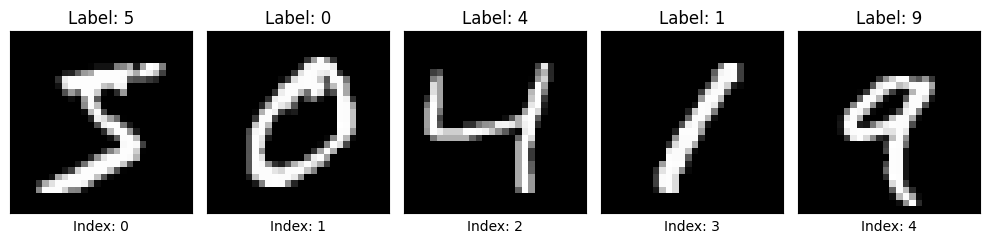

In [4]:
imagenes_ejemplo = np.stack([train_dataset[i][0].squeeze().numpy() for i in range(5)])

etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]

ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

Cambiamos a capas CONV2d para procesar los datos conservando su formato de imagen 2D, en lugar de aplanarlos.

Ademas agregamos capas de Normalizacion entre las capa CONV2d y las de activacion ReLU

Agregamos un bottleneck para llevar hasta el espacio latente que se seleccionó de 8, podemos aumentar o disminuir para probar cuál conviene.


In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        
        self.latent_dim = latent_dim

        #Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Flatten()
        )

        #bottleneck
        self.bottleneck = nn.Linear(1152, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 1152)

        #Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        flat_enconded = self.encoder(x)
        latent_space = self.bottleneck(flat_enconded)

        z_projected = self.decoder_input(latent_space)
        z_reshaped = z_projected.view(-1, 128, 3, 3)

        decoded = self.decoder(z_reshaped)

        return decoded

Definimos una función de entrenamiento con los parametros 

In [6]:
def train_AutoEncoder_conv(dataset, learning_rate=1e-3, num_epochs=20, batch_size=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = AutoEncoder(latent_dim=8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    m_s_e = nn.MSELoss(reduction='sum')
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded = model(images)
            loss = m_s_e(decoded, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader.dataset)
        print(f'Epoch: {epoch +1}/{num_epochs} | Loss = {epoch_loss:.6f}')

    return model

Entrenamos la red durante 30 épocas

In [7]:
model= train_AutoEncoder_conv(train_dataset, num_epochs=30, batch_size=64)

Epoch: 1/30 | Loss = 22.791257
Epoch: 2/30 | Loss = 14.175796
Epoch: 3/30 | Loss = 13.014153
Epoch: 4/30 | Loss = 12.375495
Epoch: 5/30 | Loss = 11.928423
Epoch: 6/30 | Loss = 11.584706
Epoch: 7/30 | Loss = 11.319543
Epoch: 8/30 | Loss = 11.110816
Epoch: 9/30 | Loss = 10.908475
Epoch: 10/30 | Loss = 10.765138
Epoch: 11/30 | Loss = 10.644643
Epoch: 12/30 | Loss = 10.514605
Epoch: 13/30 | Loss = 10.410163
Epoch: 14/30 | Loss = 10.329460
Epoch: 15/30 | Loss = 10.243340
Epoch: 16/30 | Loss = 10.172188
Epoch: 17/30 | Loss = 10.105945
Epoch: 18/30 | Loss = 10.045538
Epoch: 19/30 | Loss = 9.969871
Epoch: 20/30 | Loss = 9.920937
Epoch: 21/30 | Loss = 9.868781
Epoch: 22/30 | Loss = 9.828124
Epoch: 23/30 | Loss = 9.772945
Epoch: 24/30 | Loss = 9.746053
Epoch: 25/30 | Loss = 9.697056
Epoch: 26/30 | Loss = 9.656284
Epoch: 27/30 | Loss = 9.609237
Epoch: 28/30 | Loss = 9.580652
Epoch: 29/30 | Loss = 9.554311
Epoch: 30/30 | Loss = 9.527669


Visualizamos algunos ejemplos

In [8]:
n = 5

device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images[:n].to(device) 

    reconstructed = model(images) 

images_np = images.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

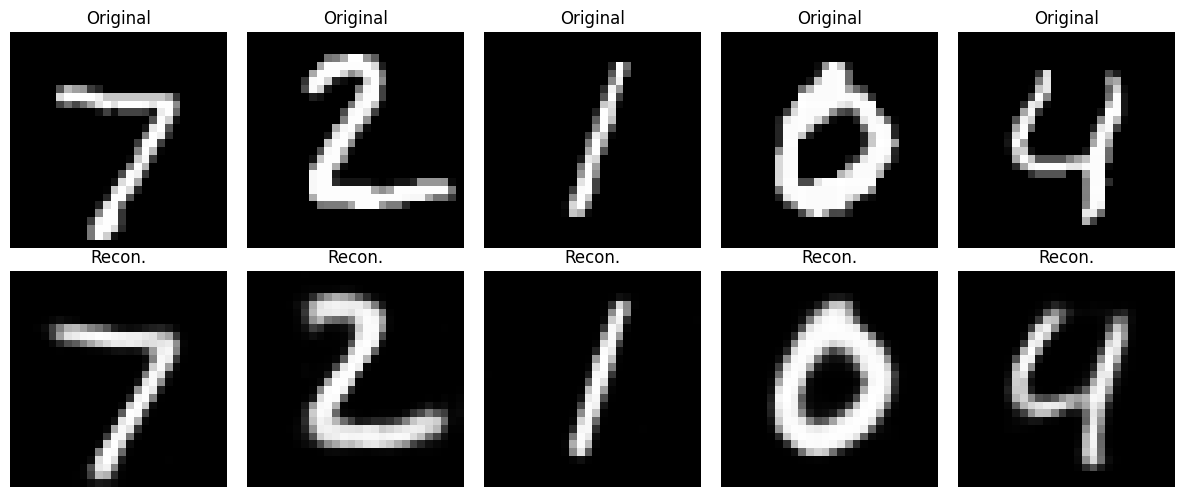

In [9]:
n = 5

fig, axes = plt.subplots(2, n, figsize=(12,5))

for i in range(n):

    img_original = images_np[i].squeeze()

    axes[0, i].imshow(img_original, cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    img_reconstruida = reconstructed_np[i].squeeze()

    axes[1, i].imshow(img_reconstruida, cmap='gray')
    axes[1, i].set_title("Recon.")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Para crear el VAE, tomamos como base la estructura de un Autoencoder tradicional, pero modificamos el bottleneck utilizando dos capas lineales en paralelo para calcular la media y el logaritmo de la varianza

Se usa el truco de reparametrización que sigue:
$$z = \mu + \epsilon * \sigma$$

Donde:
* $\mu$ (mu): Es el vector de medias predicho por el *encoder*.
* $\sigma$ (sigma): Es la desviación estándar, calculada a partir del `log_var` que predice la red.
* $\epsilon$ (epsilon): Es una variable aleatoria de ruido muestreada de una distribución normal estándar: $\epsilon \sim \mathcal{N}(0, I)$.


In [10]:
class VAE(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim

        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten() 
        )

        #Obtenemos media y log_var// En nuestro bottleneck
        self.mu = nn.Linear(1152, latent_dim)
        self.log_var = nn.Linear(1152, latent_dim)

        # DECODER
        self.decoder_input = nn.Linear(latent_dim, 1152)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def reparametrizacion(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.mu(hidden)
        log_var = self.log_var(hidden)
        
        z = self.reparametrizacion(mu, log_var)
        
        z_projected = self.decoder_input(z)
        z_reshaped = z_projected.view(-1, 128, 3, 3) 
        
        decoded = self.decoder(z_reshaped)
        return decoded, mu, log_var

Calculamos la funcion de pérdida, nótese que aqui usamos una variante de VAE conocida como $\beta$-VAE. Esta variante introduce un factor de escala, $\beta$, para modular el peso de la divergencia KL en la función de pérdida, lo que nos permite relajar la regularización latente y priorizar la reconstrucción. Como primer aproximación usamos un $\beta = 0.1$

In [11]:
def loss_function_beta(recon_x, x, mu, log_var, beta=0.1):
    BCE = F.binary_cross_entropy(recon_x.view(recon_x.size(0), -1), x.view(x.size(0), -1), reduction='sum')
    KLD = -0.5 *torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    total_loss = BCE + (beta*KLD)

    return total_loss, BCE, KLD

Definimos el entrenamiento con los parametros necesarios.

- Usamos lr = 0.001 al inicio del entrenamiento
- Optimizador Adam
- Como preparacion para las imagenes más complejas entrenamso durante 100 épocas
- Agregamos un Schedulre para el learning rate para refinar el entrenamiento de la red neuronal. Multiplica el reaning rate en un factor de 0.5 cada 30 épocas.

In [12]:
def train_VAE_conv(dataset, learning_rate=1e-3, num_epochs=100, batch_size=64, beta=0.1):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = VAE(latent_dim=8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_bce = 0.0
        total_kld = 0.0
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded, mu, log_var = model(images)
            loss, bce, kld = loss_function_beta(decoded, images, mu, log_var, beta=beta)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()

        scheduler.step()

        current_lr = scheduler.get_last_lr()[0]

        epoch_loss = total_loss / len(train_loader.dataset)
        epoch_bce = total_bce / len(train_loader.dataset)
        epoch_kld = total_kld / len(train_loader.dataset)
        
        print(f'Epoch: {epoch + 1}/{num_epochs} | LR: {current_lr:.6f} | Loss Total: {epoch_loss:.6f} | BCE: {epoch_bce:.6f} | KLD: {epoch_kld:.6f}')

    return model

In [13]:
model2 = train_VAE_conv(train_dataset, num_epochs=100, batch_size=64, beta = 0.1)

Epoch: 1/100 | LR: 0.001000 | Loss Total: 120.027628 | BCE: 117.275257 | KLD: 27.523706
Epoch: 2/100 | LR: 0.001000 | Loss Total: 95.992575 | BCE: 93.141381 | KLD: 28.511940
Epoch: 3/100 | LR: 0.001000 | Loss Total: 92.647346 | BCE: 89.821657 | KLD: 28.256892
Epoch: 4/100 | LR: 0.001000 | Loss Total: 90.688725 | BCE: 87.875269 | KLD: 28.134555
Epoch: 5/100 | LR: 0.001000 | Loss Total: 89.328916 | BCE: 86.522895 | KLD: 28.060212
Epoch: 6/100 | LR: 0.001000 | Loss Total: 88.274702 | BCE: 85.478988 | KLD: 27.957136
Epoch: 7/100 | LR: 0.001000 | Loss Total: 87.447231 | BCE: 84.645494 | KLD: 28.017372
Epoch: 8/100 | LR: 0.001000 | Loss Total: 86.727019 | BCE: 83.927470 | KLD: 27.995488
Epoch: 9/100 | LR: 0.001000 | Loss Total: 86.131992 | BCE: 83.331133 | KLD: 28.008592
Epoch: 10/100 | LR: 0.001000 | Loss Total: 85.639383 | BCE: 82.835929 | KLD: 28.034537
Epoch: 11/100 | LR: 0.001000 | Loss Total: 85.303000 | BCE: 82.497765 | KLD: 28.052351
Epoch: 12/100 | LR: 0.001000 | Loss Total: 84.8246

Graficamos algunos ejemplos

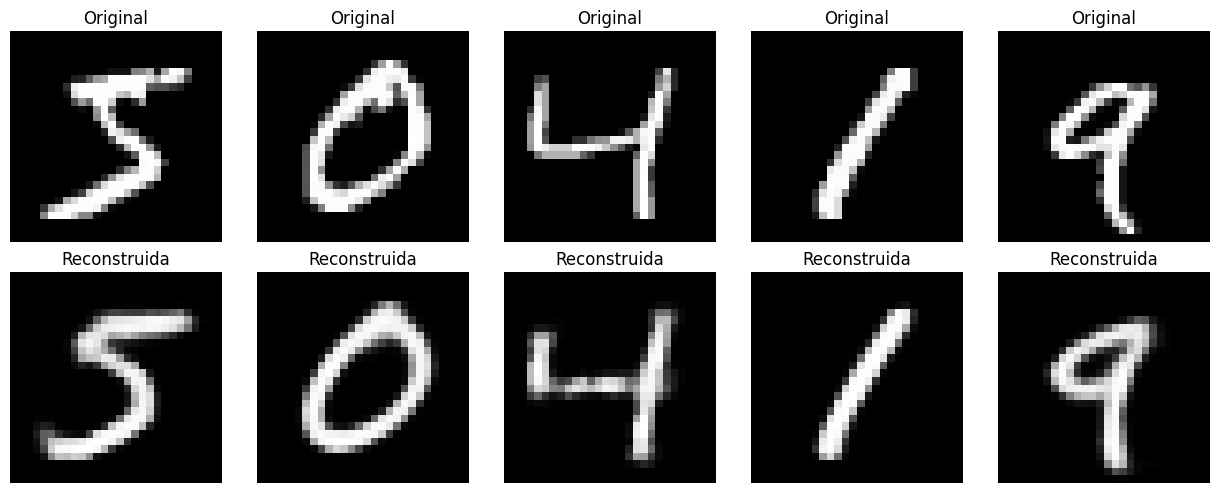

In [14]:
def reconstrucciones(model, dataset, num_images=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    
    images = torch.stack([dataset[i][0] for i in range(num_images)]).to(device)
    
    with torch.no_grad():
        decoded, _, _ = model(images)
        
    images = images.cpu()
    decoded = decoded.cpu()
    
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2.5, 5))
    
    for i in range(num_images):
        axes[0, i].imshow(images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title('Original')
            
        axes[1, i].imshow(decoded[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title('Reconstruida')
            
    plt.tight_layout()
    plt.show()

reconstrucciones(model2, train_dataset)